# Without m

In [103]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import cross_val_score

In [104]:
X,y = make_regression(n_samples=100,n_features=1,n_informative=1,n_targets=1,noise=20)

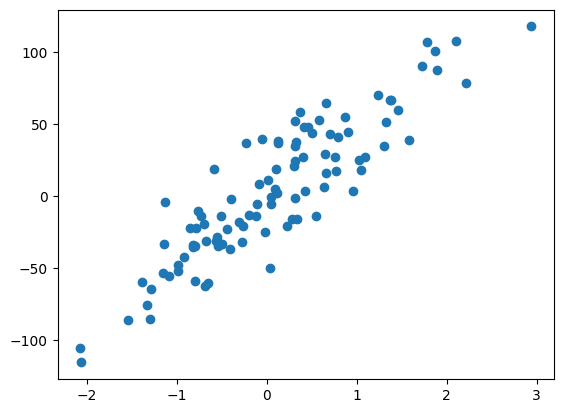

In [105]:
plt.scatter(X,y)

In [106]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [107]:
print(lr.coef_)
print(lr.intercept_)

[45.03700149]
0.07511748534397888


In [108]:
m = 49.83

In [109]:
class GDRegressor:
    
    def __init__(self,learning_rate,epochs):
        self.m = 49.83
        self.b = -120
        self.lr = learning_rate
        self.epochs = epochs

    def fit(self,X,y):
        # Calculate the b using GD
        for i in range (self.epochs):
            loss_slope = -2 * np.sum(y - self.m * X.ravel() - self.b) 
            self.b = self.b - (self.lr * loss_slope)
            print(loss_slope,self.b)
        print(self.b)

        

In [110]:
gd = GDRegressor(0.001,100)
gd.fit(X,y)

-23933.788463287932 -96.06621153671207
-19147.030770630343 -76.91918076608172
-15317.62461650427 -61.601556149577455
-12254.09969320342 -49.34745645637403
-9803.279754562733 -39.5441767018113
-7842.623803650188 -31.701552898161115
-6274.099042920152 -25.427453855240962
-5019.27923433612 -20.408174620904845
-4015.4233874688966 -16.39275123343595
-3212.3387099751176 -13.18041252346083
-2569.870967980093 -10.610541555480737
-2055.8967743840753 -8.55464478109666
-1644.7174195072596 -6.909927361589402
-1315.773935605808 -5.594153425983594
-1052.6191484846463 -4.541534277498947
-842.0953187877168 -3.69943895871123
-673.6762550301736 -3.025762703681057
-538.9410040241388 -2.486821699656918
-431.15280321931107 -2.055668896437607
-344.922242575449 -1.710746653862158
-275.93779406035935 -1.4348088598017987
-220.75023524828725 -1.2140586245535114
-176.60018819862992 -1.0374584363548816
-141.28015055890393 -0.8961782857959777
-113.02412044712305 -0.7831541653488546
-90.41929635769846 -0.6927348689

# With m 

In [125]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import cross_val_score

In [126]:
X,y = make_regression(n_samples=100,n_features=1,n_informative=1,n_targets=1,noise=20,random_state=13)

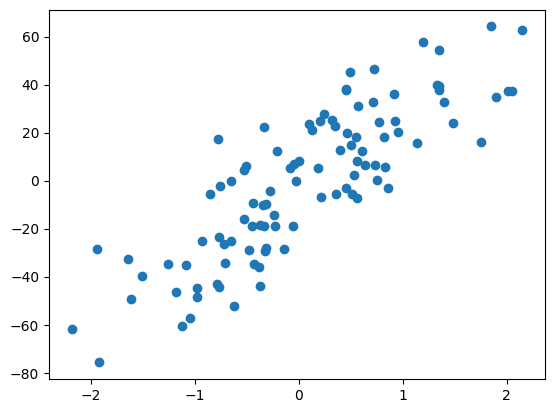

In [127]:
plt.scatter(X,y)

In [141]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)


In [144]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [145]:
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [146]:
print(lr.coef_)
print(lr.intercept_)

[28.12597332]
-2.271014426178382


In [153]:
y_pred = lr.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.6345158782661013

In [148]:
class GDRegressor:
    
    def __init__(self,learning_rate,epochs):
        self.m = 100
        self.b = -120
        self.lr = learning_rate
        self.epochs = epochs

    def fit(self,X,y):
        # Calculate the b using GD
        for i in range (self.epochs):
            loss_slope_b = -2 * np.sum(y - self.m * X.ravel() - self.b) 
            loss_slope_m = -2 * np.sum((y - self.m * X.ravel() - self.b)*X.ravel()) 
            self.b = self.b - (self.lr * loss_slope_b)
            self.m = self.m - (self.lr * loss_slope_m)
        print(self.m,self.b)

    def predict(self,X):
        return self.m * X + self.b
        

In [149]:
gd = GDRegressor(0.001,60)
gd.fit(X,y)

27.82950284554023 -2.2953893605809816


In [151]:
y_pred = gd.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.6357775733242531

In [152]:
# np.mean(cross_val_score(gd,X,y,scoring='r2',cv=10))